In [2]:
import pandas as pd
df = pd.read_pickle('/Users/yang./Desktop/测试数据-2020至今.pk')
df = df.dropna()
dp = df['close'].unstack()
dp

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-01-02,1841.6882,4832.2920,90.7460,29.1003,191.3002,79.1077,82.8549,59.0007,36.7412,34.2681,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,1875.5308,4756.6019,90.8273,29.1929,194.1343,78.7764,83.7482,56.6974,36.7412,34.1960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,1863.5221,4676.4595,88.3890,29.1929,193.4257,78.5278,83.3015,62.3672,36.9567,33.8357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,1872.2557,4713.5625,89.8114,29.6563,194.4885,78.7764,84.6415,63.4302,38.1419,34.4122,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,1818.7627,4701.6895,88.5109,29.1929,190.9459,77.8652,83.0782,62.9873,37.8187,33.4753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,999.0840,1231.9517,35.4775,7.6921,249.1678,60.3041,63.8636,81.3312,36.6335,38.8147,...,59.5828,25.4327,84.18,33.5764,18.7988,11.7315,32.71,44.7558,27.8200,513.4781
2025-07-28,1007.9827,1233.7687,35.8839,7.6921,254.3339,60.3041,63.4155,83.7549,37.2799,38.7265,...,59.7254,25.3779,83.14,35.5440,18.8832,11.6704,33.81,44.6235,27.3663,516.2475
2025-07-29,998.2750,1237.4028,35.7620,7.6921,251.9495,59.5586,63.4155,82.6777,37.2799,39.0353,...,60.2673,25.3011,88.46,34.6663,19.0309,11.5889,34.90,45.4177,27.1747,526.7832


In [3]:
future_df = dp.shift(-20) / dp - 1
future_df

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-01-02,-0.133373,-0.155405,-0.034035,-0.095542,-0.162963,-0.207330,-0.177898,-0.010510,0.000000,-0.188225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.155995,-0.105460,-0.020134,-0.088888,-0.162409,-0.124080,-0.165334,0.132812,0.005865,-0.173868,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,-0.133568,-0.077118,-0.017472,-0.095235,-0.146520,-0.147679,-0.163538,0.015624,0.000000,-0.149097,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,-0.138776,-0.084383,-0.021268,-0.103125,-0.149363,-0.145111,-0.171505,0.012570,-0.031073,-0.162303,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,-0.120648,-0.054609,-0.022038,-0.107934,-0.135436,-0.136171,-0.163979,-0.004220,-0.031339,-0.138858,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
momentum_20 = dp.pct_change(20)
lower = momentum_20.quantile(0.05,axis=1)
upper = momentum_20.quantile(0.95,axis=1)
momentum_20 = momentum_20.clip(lower=lower.values.reshape(-1,1),upper=upper.values.reshape(-1,1),axis=1)
momentum_20 = (momentum_20 - momentum_20.mean(axis=1).values.reshape(-1,1)) / momentum_20.std(axis=1).values.reshape(-1,1)
momentum_20

/var/folders/zt/lhp1r6t56dg6llm53jc0td680000gn/T/ipykernel_2139/2848506220.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  momentum_20 = dp.pct_change(20)


code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,-0.680610,-0.060583,-0.748996,-0.837024,-1.483672,-1.483672,-0.516711,-0.461158,0.907434,-0.294420,...,0.028011,-0.376392,0.608659,-0.147205,-0.332350,-0.295955,0.980993,2.516072,0.744098,-0.358802
2025-07-28,-0.310925,0.014598,-0.755379,-0.726318,-0.825977,-1.283788,-0.541990,-0.074841,1.195640,-0.224272,...,-0.003280,-0.429025,0.068350,0.669948,-0.341722,-0.249344,1.787582,2.381184,0.379772,-1.046472
2025-07-29,-0.623240,0.217523,-0.945979,-0.662758,-0.757843,-1.242164,-0.444205,-0.556274,1.389863,-0.057343,...,0.072133,-0.413975,1.240711,0.482884,-0.179492,-0.311254,1.734232,2.294850,0.232872,-0.443617


In [5]:
momentum_20_long = momentum_20.stack()
df['momentum_20_long'] = momentum_20_long
df

close      free_mkt   industry  status  \
trade_dt   code                                                    
2020-01-02 000001.SZ  1841.6882  1.451008e+11  801780.SI       0   
           000002.SZ  4832.2920  1.976077e+11  801180.SI       0   
           000004.SZ    90.7460  1.190862e+09  801150.SI       0   
           000005.SZ    29.1003  2.592888e+09  801160.SI       0   
           000006.SZ   191.3002  4.656473e+09  801180.SI       0   
...                         ...           ...        ...     ...   
2025-07-31 688799.SH    84.7347  4.446411e+09  801150.SI       0   
           688800.SH    99.1180  7.097760e+09  801080.SI       0   
           688819.SH    30.1375  3.717844e+09  801730.SI       0   
           688981.SH    89.5000  1.511312e+11  801080.SI       0   
           689009.SH    62.0949  3.241894e+10  801880.SI       0   

                      momentum_20_long  
trade_dt   code                         
2020-01-02 000001.SZ               NaN  
           000002.SZ               NaN  
           000004.SZ               NaN  
           000005.SZ               NaN  
           000006.SZ               NaN  
...                                ...  
2025-07-31 688799.SH          1.741121  
           688800.SH          1.879887  
           688819.SH         -0.296690  
           688981.SH          0.018799  
           689009.SH         -0.680853  

[5974269 rows x 5 columns]

In [6]:
import numpy as np
import statsmodels.api as sm
def neutralize(df):
    neutralize_results = []
    corr_results = []
    for date,group in df.groupby('trade_dt'):
        dp = group.copy()

        dp = dp[dp['free_mkt'] > 0]
        dp['log_free_mkt'] = np.log(dp['free_mkt'])
        lower = dp['log_free_mkt'].quantile(0.05)
        upper = dp['log_free_mkt'].quantile(0.95)
        dp['log_free_mkt'] = dp['log_free_mkt'].clip(lower,upper)
        dp['log_free_mkt'] = (dp['log_free_mkt'] - dp['log_free_mkt'].mean()) / dp['log_free_mkt'].std()
        industry_dummies = pd.get_dummies(dp['industry'],dtype=float)

        #第一步：市值对行业中性化
        x_mkt = industry_dummies
        x_mkt = sm.add_constant(x_mkt)
        y_mkt = dp['log_free_mkt']
        #处理缺失值
        valid_mkt = y_mkt.notna() & x_mkt.notna().all(axis=1)
        y_mkt = y_mkt[valid_mkt]
        x_mkt = x_mkt[valid_mkt]
        if len(y_mkt) < 10:
            continue
        #回归
        model_mkt = sm.OLS(y_mkt,x_mkt).fit()
        #残差=对行业中性化后的市值
        dp.loc[valid_mkt,'mkt_neutral'] = model_mkt.resid

        #第二步：因子对市值、行业中性化
        y_factor = dp['momentum_20_long']
        x_factor = pd.concat([dp['mkt_neutral'],industry_dummies],axis=1)
        x_factor = sm.add_constant(x_factor)

        valid_factor = y_factor.notna() & x_factor.notna().all(axis=1)
        y_factor = y_factor[valid_factor]
        x_factor = x_factor[valid_factor]
        if len(y_factor) < 10:
            continue
        model_factor = sm.OLS(y_factor,x_factor).fit()

        dp.loc[valid_factor,'neutral_momentum_20'] = model_factor.resid

        #因子中性化前后因子与市值相关性对比
        corr_before_df = dp[['momentum_20_long', 'log_free_mkt']].dropna()
        corr_after_df = dp[['neutral_momentum_20', 'log_free_mkt']].dropna()

        corr_before = np.nan
        corr_after = np.nan

        if len(corr_before_df) >= 2:
            corr_before = corr_before_df['momentum_20_long'].corr(corr_before_df['log_free_mkt'])

        if len(corr_after_df) >= 2:
            corr_after = corr_after_df['neutral_momentum_20'].corr(corr_after_df['log_free_mkt'])

        corr_results.append({
            'date': date,
            'corr_before': corr_before,
            'corr_after': corr_after
        })
        corr_results_df = pd.DataFrame(corr_results).set_index('date')
        
        neutralize_results.append(dp[['mkt_neutral','neutral_momentum_20']])
    neutralize_results_df = pd.concat(neutralize_results)
    return neutralize_results_df,corr_results_df

In [7]:
momentum_20_neutral,corr_compare = neutralize(df)
momentum_20_neutral

mkt_neutral  neutral_momentum_20
trade_dt   code                                       
2020-02-07 000001.SZ     0.528828            -0.260528
           000002.SZ     2.004958            -0.680077
           000004.SZ    -1.199473            -0.732494
           000005.SZ    -0.036592            -0.091568
           000006.SZ     0.276317            -0.300532
...                           ...                  ...
2025-07-31 688799.SH    -0.023388             1.003401
           688800.SH     0.353419             1.824444
           688819.SH    -0.092463            -0.139181
           688981.SH     1.815182            -0.208498
           689009.SH     2.148954            -0.775244

[5898564 rows x 2 columns]

In [8]:
corr_compare

,corr_before,corr_after
date,,
2020-02-07,0.269420,-1.212007e-15
2020-02-10,0.262004,-9.313716e-16
2020-02-11,0.280547,-1.084448e-15
2020-02-12,0.288067,-6.099242e-16
2020-02-13,0.299227,-7.555261e-16
...,...,...
2025-07-25,0.091266,1.948042e-16
2025-07-28,0.086117,-1.184906e-16
2025-07-29,0.129728,2.034466e-16


In [9]:
print(f"corr_mean_before:{corr_compare['corr_before'].mean():.20f},corr_mean_after:{corr_compare['corr_after'].mean():.20f}")

corr_mean_before:0.05258513083356392698,corr_mean_after:0.00000000000000003669


In [10]:
future_long = future_df.stack()
momentum_20_neutral['future_long'] = future_long
momentum_20_neutral

mkt_neutral  neutral_momentum_20  future_long
trade_dt   code                                                    
2020-02-07 000001.SZ     0.528828            -0.260528     0.028044
           000002.SZ     2.004958            -0.680077     0.132000
           000004.SZ    -1.199473            -0.732494     0.942513
           000005.SZ    -0.036592            -0.091568     0.073944
           000006.SZ     0.276317            -0.300532     0.095133
...                           ...                  ...          ...
2025-07-31 688799.SH    -0.023388             1.003401          NaN
           688800.SH     0.353419             1.824444          NaN
           688819.SH    -0.092463            -0.139181          NaN
           688981.SH     1.815182            -0.208498          NaN
           689009.SH     2.148954            -0.775244          NaN

[5898564 rows x 3 columns]

In [11]:
future_df = momentum_20_neutral['future_long'].unstack()
future_df

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-02-07,0.028044,0.132000,0.942513,0.073944,0.095133,0.216645,0.137705,0.215479,0.082112,0.073837,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-10,-0.003448,0.065574,0.821461,0.055749,0.045751,0.132053,0.130991,0.051036,0.037901,0.025511,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-11,-0.002028,0.059147,0.910155,0.077190,0.040772,0.126238,0.157051,0.076924,0.049563,0.007509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-12,-0.005416,0.044704,0.834952,0.076656,0.044968,0.093481,0.149682,0.015173,0.049563,0.008749,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-13,0.002048,0.000000,0.803285,0.056939,0.023605,0.046799,0.122187,-0.014124,0.047058,0.002498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-07-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
momentum_20 = momentum_20_neutral['neutral_momentum_20'].unstack()
momentum_20 = (momentum_20 - momentum_20.mean(axis=1).values.reshape(-1,1)) / momentum_20.std(axis=1).values.reshape(-1,1)
momentum_20

code,000001.SZ,000002.SZ,000004.SZ,000005.SZ,000006.SZ,000007.SZ,000008.SZ,000009.SZ,000010.SZ,000011.SZ,...,688259.SH,300834.SZ,688220.SH,301117.SZ,301158.SZ,301116.SZ,688062.SH,301201.SZ,301286.SZ,302132.SZ
trade_dt,,,,,,,,,,,,,,,,,,,,,
2020-02-07,-0.306104,-0.799049,-0.860635,-0.107587,-0.353107,-0.716766,-1.292699,-0.259285,0.965487,-0.179157,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-10,-0.538668,-0.516301,-0.617947,-0.120693,-0.483286,-0.210422,-1.345707,0.868828,0.917867,-0.188819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-11,-0.501893,-0.306216,-0.567475,-0.040242,-0.414758,-0.357053,-1.321456,0.013510,0.945191,-0.024232,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-12,-0.531040,-0.370634,-0.505508,-0.112619,-0.400036,-0.285110,-1.428132,0.009832,0.662186,-0.090499,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-02-13,-0.424191,-0.257837,-0.488484,-0.217126,-0.409337,-0.218568,-1.383871,-0.194584,0.613893,-0.000569,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-25,0.147838,-0.324101,-0.530653,-0.645607,-1.635835,-1.172610,-0.731700,-0.748490,0.920528,-0.244980,...,0.319876,-0.335727,0.694758,0.044896,-0.399892,-0.236302,0.295013,2.051061,0.846593,-0.748370
2025-07-28,0.281891,-0.302901,-0.517202,-0.564249,-1.025043,-1.056343,-0.721281,-0.316090,1.279736,-0.273321,...,0.191046,-0.416687,0.062813,0.926571,-0.393626,-0.247449,1.103337,1.847845,0.435159,-1.411318
2025-07-29,0.264522,-0.295437,-0.812831,-0.308711,-1.081244,-0.933097,-0.652512,-0.855288,1.461495,-0.171667,...,0.191294,-0.230763,1.115379,0.612440,-0.202959,-0.108916,1.090928,1.859640,0.452196,-0.888687


In [13]:
def ic(factor_df,future_df,start_idx):
    ic_results = []
    for i in range(start_idx,len(factor_df)-20):
        factor = factor_df.iloc[i]
        future = future_df.iloc[i]
        dp = pd.DataFrame({
            'factor':factor,
            'future':future
        }).dropna()
        ic = dp['factor'].corr(dp['future'],method = 'spearman')
        ic_results.append({
            'date':factor_df.index[i],
            'ic':ic
        })
    ic_results_df = pd.DataFrame(ic_results)
    ic_results_df['date'] = pd.to_datetime(ic_results_df['date'])
    ic_results_df = ic_results_df.set_index('date')
    ic_results_df['cum_ic'] = ic_results_df['ic'].cumsum()
    return ic_results_df

In [14]:
momentum_20_ic = ic(momentum_20,future_df,30)
momentum_20_ic

,ic,cum_ic
date,,
2020-03-20,-0.101146,-0.101146
2020-03-23,-0.115532,-0.216677
2020-03-24,-0.076862,-0.293539
2020-03-25,-0.029489,-0.323028
2020-03-26,-0.023179,-0.346207
...,...,...
2025-06-27,-0.067968,-71.085878
2025-06-30,-0.023577,-71.109455
2025-07-01,-0.021529,-71.130984


In [15]:
print((momentum_20_ic['ic'] > 0).mean())
print(f"rank ic mean:{momentum_20_ic['ic'].mean()}")
print(f"rank ic std:{momentum_20_ic['ic'].std()}")
print(f"rank icir:{momentum_20_ic['ic'].mean() / momentum_20_ic['ic'].std()}")

0.29195940671350507
rank ic mean:-0.05558137808418021
rank ic std:0.09854698871663248
rank icir:-0.5640088937065547


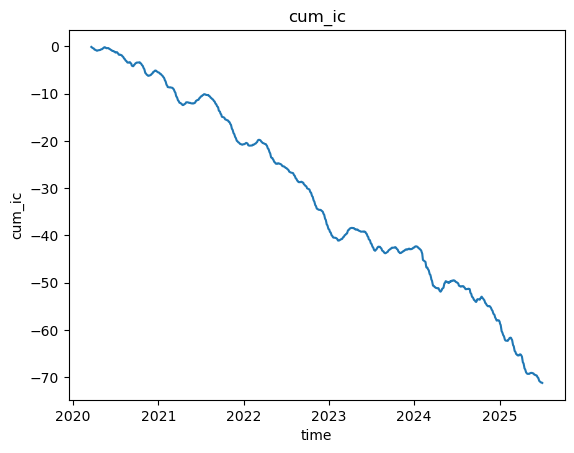

In [16]:
import matplotlib.pyplot as plt
plt.plot(momentum_20_ic['cum_ic'])
plt.xlabel('time')
plt.ylabel('cum_ic')
plt.title('cum_ic')
plt.savefig('rank_ic.png')
plt.show()

In [17]:
def group(factor_df,future_df,start_idx,n_groups):
    group_results = []
    test_date = momentum_20.index[start_idx:len(factor_df)-20:20]
    for date in test_date:
        factor = factor_df.loc[date]
        future = future_df.loc[date]
        dp = pd.DataFrame({
            'factor':factor,
            'future':future
        }).dropna()
        dp['rank'] = dp['factor'].rank()
        dp['quantile'] = pd.qcut(dp['rank'],n_groups,labels=False)
        group_return = dp.groupby('quantile')['future'].mean()
        group_return['date'] = date
        group_results.append(group_return)
    group_results_df = pd.DataFrame(group_results)
    group_results_df['date'] = pd.to_datetime(group_results_df['date'])
    group_results_df = group_results_df.set_index('date')
    group_results_df['long_short'] = group_results_df[0] - group_results_df[n_groups - 1]
    return group_results_df

In [18]:
group_momentum_20 = group(momentum_20,future_df,30,10)
group_momentum_20

quantile,0,1,2,3,4,5,6,7,8,9,long_short
date,,,,,,,,,,,
2020-03-20,0.024912,0.018878,0.019869,0.025502,0.024353,0.025273,0.012199,0.012665,0.002116,-0.002528,0.027440
2020-04-20,-0.026786,-0.020384,-0.014318,-0.006526,-0.008074,-0.001945,-0.004575,0.007644,-0.004812,-0.024122,-0.002664
2020-05-21,0.073782,0.065887,0.056358,0.055935,0.053715,0.056692,0.060180,0.061745,0.063352,0.070380,0.003402
2020-06-18,0.113932,0.122852,0.134082,0.142695,0.138603,0.125187,0.141650,0.135442,0.124271,0.108758,0.005174
2020-07-20,0.034353,0.054591,0.048029,0.045491,0.047005,0.052510,0.050772,0.047221,0.060566,0.053957,-0.019605
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-06,-0.030014,0.010053,0.005805,-0.003587,-0.007609,-0.005284,-0.015573,-0.038623,-0.051128,-0.091382,0.061368
2025-04-03,0.006613,-0.001340,0.008856,-0.007961,0.000136,-0.002167,-0.003122,-0.005238,0.003121,0.015366,-0.008753
2025-05-07,0.044868,0.037952,0.036246,0.031598,0.033760,0.037589,0.028936,0.038283,0.057890,0.043563,0.001305


In [19]:
the_group_results = []
for columns in group_momentum_20.columns:
    cumprod = (1 + group_momentum_20[columns]).cumprod()
    cummax = cumprod.cummax()
    annual_return = cumprod.iloc[-1] ** (252 / (len(group_momentum_20[columns]) * 20)) - 1
    annual_volatility = group_momentum_20[columns].std() * (252/20) ** 0.5
    sharpe = group_momentum_20[columns].mean() / group_momentum_20[columns].std() * (252/20) ** 0.5
    drawdown = (cumprod - cummax) / cummax
    max_drawdown = drawdown.min()
    the_group_results.append({
        'group':columns,
        'annual_return':annual_return,
        'volatility':annual_volatility,
        'sharpe':sharpe,
        'max_drawdown':max_drawdown
    })
the_group_results_df = pd.DataFrame(the_group_results)
the_group_results_df = the_group_results_df.set_index('group')
the_group_results_df

,annual_return,volatility,sharpe,max_drawdown
group,,,,
0,0.075729,0.246780,0.414516,-0.409095
1,0.152283,0.230899,0.727468,-0.253705
2,0.166954,0.219333,0.811924,-0.247427
3,0.169619,0.212654,0.842133,-0.258463
4,0.171042,0.203840,0.875669,-0.223004
5,0.151349,0.203688,0.792388,-0.214418
6,0.148677,0.199658,0.793036,-0.205733
7,0.130578,0.199217,0.714851,-0.226595
8,0.080185,0.202654,0.479145,-0.319886


In [20]:
cum_group_momentum_20 = (1 + group_momentum_20).cumprod()
cum_group_momentum_20

quantile,0,1,2,3,4,5,6,7,8,9,long_short
date,,,,,,,,,,,
2020-03-20,1.024912,1.018878,1.019869,1.025502,1.024353,1.025273,1.012199,1.012665,1.002116,0.997472,1.027440
2020-04-20,0.997458,0.998110,1.005267,1.018809,1.016082,1.023279,1.007568,1.020405,0.997294,0.973410,1.024703
2020-05-21,1.071053,1.063872,1.061922,1.075797,1.070662,1.081291,1.068203,1.083410,1.060475,1.041919,1.028189
2020-06-18,1.193080,1.194571,1.204307,1.229307,1.219059,1.216654,1.219514,1.230150,1.192262,1.155236,1.033509
2020-07-20,1.234065,1.259784,1.262149,1.285229,1.276360,1.280540,1.281432,1.288238,1.264472,1.217570,1.013247
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-06,1.300498,1.870012,1.949592,2.020538,2.004276,1.790873,1.823232,1.654171,1.278138,0.592063,2.120180
2025-04-03,1.309098,1.867506,1.966857,2.004454,2.004549,1.786993,1.817540,1.645506,1.282127,0.601160,2.101623
2025-05-07,1.367834,1.938381,2.038148,2.067791,2.072222,1.854165,1.870131,1.708500,1.356349,0.627349,2.104365


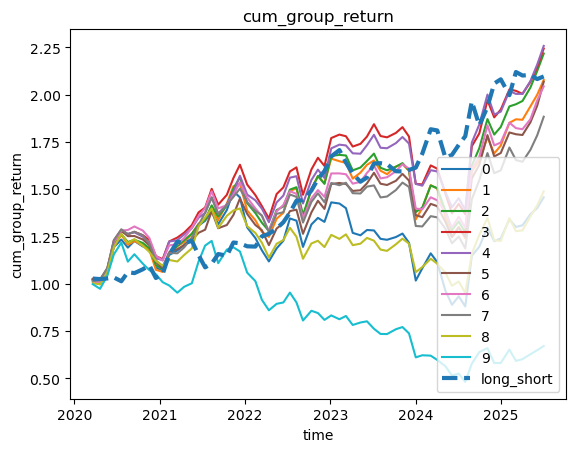

In [21]:
for columns in cum_group_momentum_20.columns:
    if columns == 'long_short':
        plt.plot(cum_group_momentum_20[columns],linestyle = '--',label = columns,linewidth = 3)
    else:
        plt.plot(cum_group_momentum_20[columns],label = columns)
plt.xlabel('time')
plt.ylabel('cum_group_return')
plt.title('cum_group_return')
plt.legend()
plt.savefig('quantile_backtest.png')
plt.show()

In [24]:
def ols(factor_df,future_df,start_idx):
    ols_results = []
    for i in range(start_idx,len(factor_df)-20):
        factor = factor_df.iloc[i]
        future = future_df.iloc[i]
        df = pd.DataFrame({
            'factor':factor,
            'future':future
        }).dropna()
        y = df['future']
        x = df['factor']
        x = sm.add_constant(x)
        model = sm.OLS(y,x).fit()
        ols_results.append({
            'date':factor_df.index[i],
            'beta':model.params['factor'],
            't': model.tvalues['factor'],
            'p': model.pvalues['factor']
        })
    ols_results_df = pd.DataFrame(ols_results)
    ols_results_df['date'] = pd.to_datetime(ols_results_df['date'])
    ols_results_df = ols_results_df.set_index('date')
    return ols_results_df

In [25]:
momentum_20_ols = ols(momentum_20,future_df,30)
momentum_20_ols

,beta,t,p
date,,,
2020-03-20,-0.007851,-4.047281,5.284937e-05
2020-03-23,-0.010107,-5.089348,3.767213e-07
2020-03-24,-0.005781,-2.864589,4.198456e-03
2020-03-25,-0.000405,-0.200445,8.411430e-01
2020-03-26,-0.001192,-0.634247,5.259578e-01
...,...,...,...
2025-06-27,-0.004359,-1.857408,6.331774e-02
2025-06-30,-0.001114,-0.423962,6.716133e-01
2025-07-01,0.000401,0.143001,8.862954e-01


In [26]:
beta_mean = momentum_20_ols['beta'].mean()
beta_rate = (momentum_20_ols['beta'] > 0).mean()
t_mean = momentum_20_ols['t'].mean()
t_rate = (abs(momentum_20_ols['t']) > 2).mean()
p_rate = (momentum_20_ols['p'] < 0.05).mean()
print(f"bata_mean:{beta_mean},bata>0:{beta_rate},t_mean:{t_mean},|t|>2:{t_rate},p<0.05:{p_rate}")

bata_mean:-0.0039627240197977415,bata>0:0.3770491803278688,t_mean:-2.187204416841735,|t|>2:0.7127244340359095,p<0.05:0.7205308352849337
